In [1]:
here::i_am("rna_atac/mofa/mofa_analysis.R")

#####################
## Define settings ##
#####################

source(here::here("settings.R"))
source(here::here("utils.R"))

here() starts at /rds/project/rds-SDzz0CATGms/users/bt392/atlasses/gastrulation_multiome/code



In [133]:
denoise = function(mat, NN){
    denoised_mat <- sapply(seq_len(ncol(mat)), function(cid){
        tmp = mat[,NN[cid,]]
        return(Matrix::rowMeans(tmp))
        })
    dimnames(denoised_mat) <- dimnames(mat)
    return(denoised_mat)
}


In [115]:
atac_lsi_no_batch_corr = fread("/rds/project/rds-SDzz0CATGms/users/bt392/atlasses/gastrulation_multiome/results/atac/archR/dimensionality_reduction/cells/PeakMatrix/remove_ExE_cells_False/batch_correction_None/lsi_nfeatures25000_ndims50.txt.gz")
atac_lsi_batch_sample = fread("/rds/project/rds-SDzz0CATGms/users/bt392/atlasses/gastrulation_multiome/results/atac/archR/dimensionality_reduction/cells/PeakMatrix/remove_ExE_cells_False/batch_correction_sample/lsi_nfeatures25000_ndims50.txt.gz")
#rna_pca_batch_stage = fread("/rds/project/rds-SDzz0CATGms/users/bt392/atlasses/gastrulation_multiome/results/rna/dimensionality_reduction/sce/batch_correction_by_stage_remove_ExE_cells_False/pca_features2500_pcs50.txt.gz")
rna_pca_batch_sample = fread("/rds/project/rds-SDzz0CATGms/users/bt392/atlasses/gastrulation_multiome/results/rna/dimensionality_reduction/sce/batch_correction_by_sample_remove_ExE_cells_False/pca_features2500_pcs50.txt.gz")

In [116]:
RNA = rna_pca_batch_sample
ATAC = atac_lsi_no_batch_corr

In [117]:
meta = fread("/rds/project/rds-SDzz0CATGms/users/bt392/atlasses/gastrulation_multiome/results/rna/mapping/sample_metadata_after_mapping.txt.gz")

In [118]:
summary(ATAC$cell == RNA$cell)

Warning message in ATAC$cell == RNA$cell:
“longer object length is not a multiple of shorter object length”


   Mode   FALSE 
logical   65420 

In [119]:
keep_cells = intersect(ATAC$cell, RNA$cell)
ATAC = ATAC[cell %in% keep_cells,]
RNA = RNA[cell %in% keep_cells,]

In [120]:
summary(ATAC$cell == RNA$cell)

   Mode    TRUE 
logical   51306 

# All dimensions

In [91]:
ATAC_dims = 50
RNA_dims = 50

joint_dimred = cbind(ATAC[,1:ATAC_dims], RNA[,2:(RNA_dims+1)])
cells = joint_dimred$cell
joint_dimred = as.data.table(apply(joint_dimred[,2:length(joint_dimred)], 2, scale))

In [92]:
meta = meta[cell %in% cells & order(match(cell, cells)),]

In [93]:
library(uwot)
options(repr.plot.width=10, repr.plot.height=8)
K = 15
nn = 20
mindist = 0.3

In [94]:
plot_umap = function(modality='RNA', colour='celltype'){
    ggplot(meta, aes_string(x=paste0(modality, '_umap1'), y=paste0(modality, '_umap2'), col=colour)) +
        geom_point() +
        ggtitle(modality) + 
        theme_void() + theme(text=element_text(size=15))
    }

In [95]:
# RNA 
RNA_UMAP = umap(RNA[,1:RNA_dims],
                n_neighbors = nn,
                min_dist = mindist)

RNA_UMAP = as.data.table(RNA_UMAP) %>%
    setnames(c('RNA_umap1', 'RNA_umap2')) %>% 
    .[, cell:=cells]

In [96]:
ATAC_UMAP = umap(ATAC[,2:ATAC_dims],
                n_neighbors = nn,
                min_dist = mindist)

ATAC_UMAP = as.data.table(ATAC_UMAP) %>%
    setnames(c('ATAC_umap1', 'ATAC_umap2')) %>% 
    .[, cell:=cells]

In [97]:
meta_new = meta %>% 
     merge(RNA_UMAP, by='cell') %>%  merge(ATAC_UMAP, by='cell')

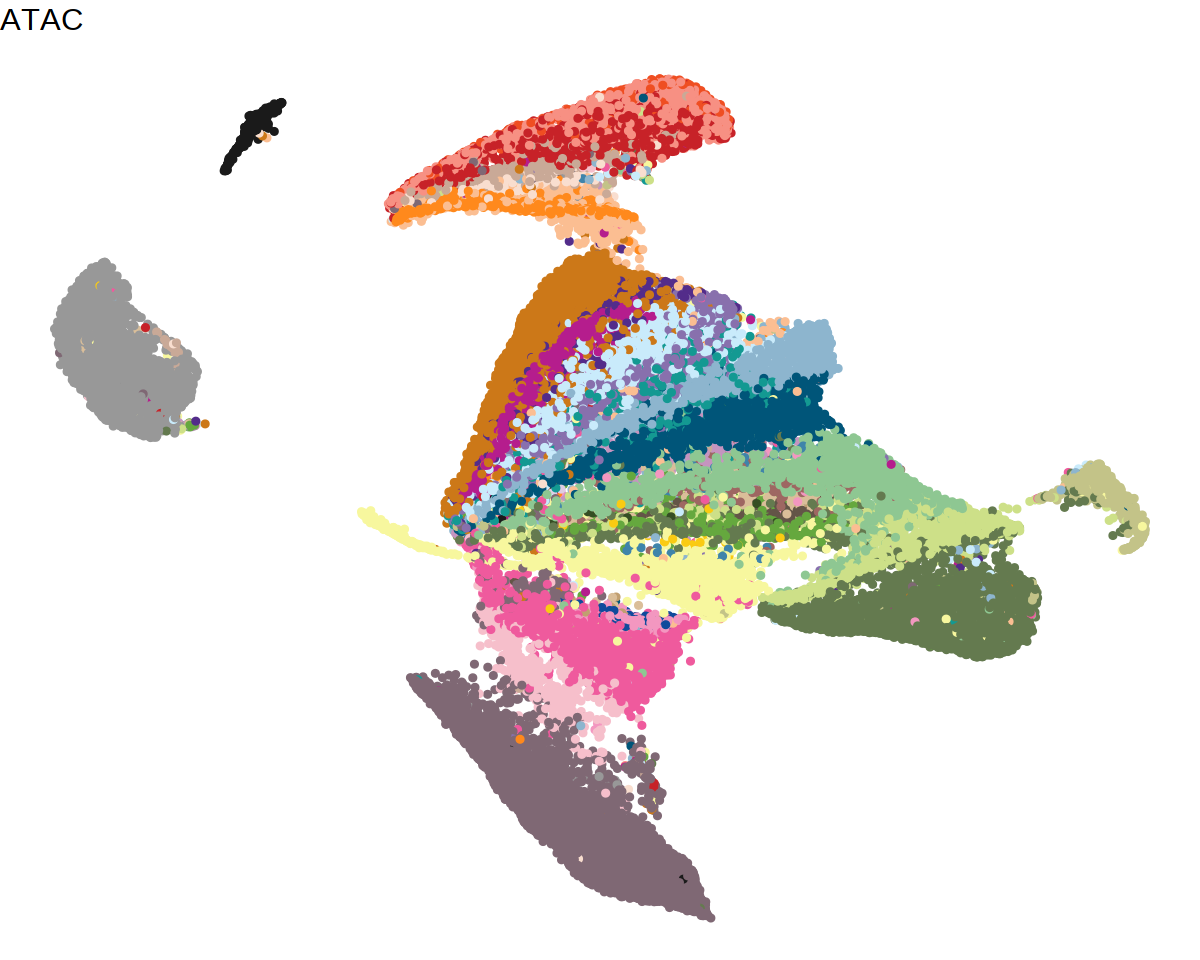

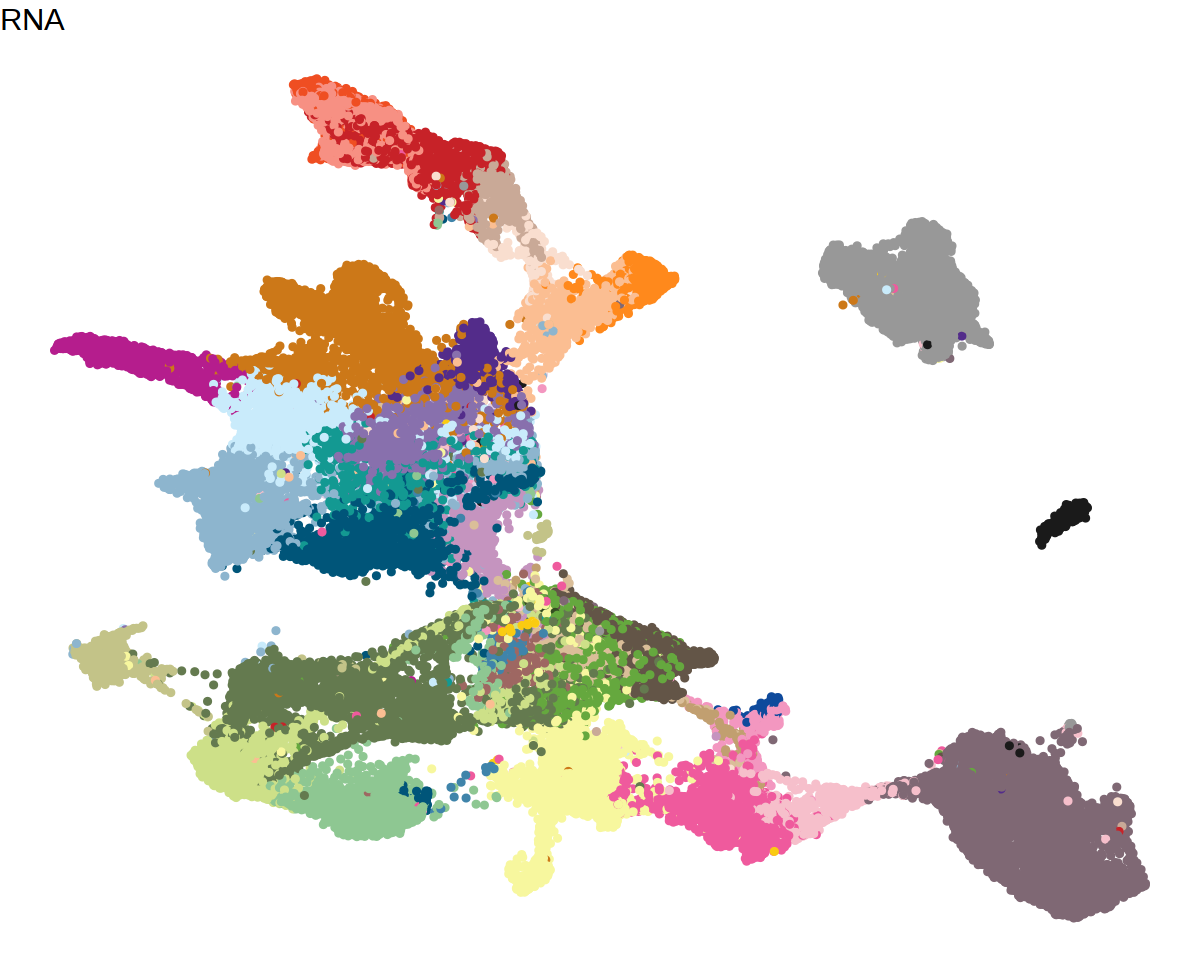

In [98]:
plot_umap = function(modality='RNA', colour='celltype'){
    ggplot(meta_new, aes_string(x=paste0(modality, '_umap1'), y=paste0(modality, '_umap2'), col=colour)) +
        geom_point() +
        ggtitle(modality) + scale_color_manual(values=opts$celltype.colors)+
        theme_void() + theme(text=element_text(size=15), legend.position='none')
    }
plot_umap('ATAC')
plot_umap('RNA')

In [99]:
joint_UMAP = umap(joint_dimred,
                n_neighbors = nn,
                min_dist = mindist)
joint_UMAP = as.data.table(joint_UMAP, keep.rownames=T) %>%
    setnames(c('joint_umap1', 'joint_umap2'))
  

In [100]:
meta_new = meta %>% cbind(joint_UMAP)

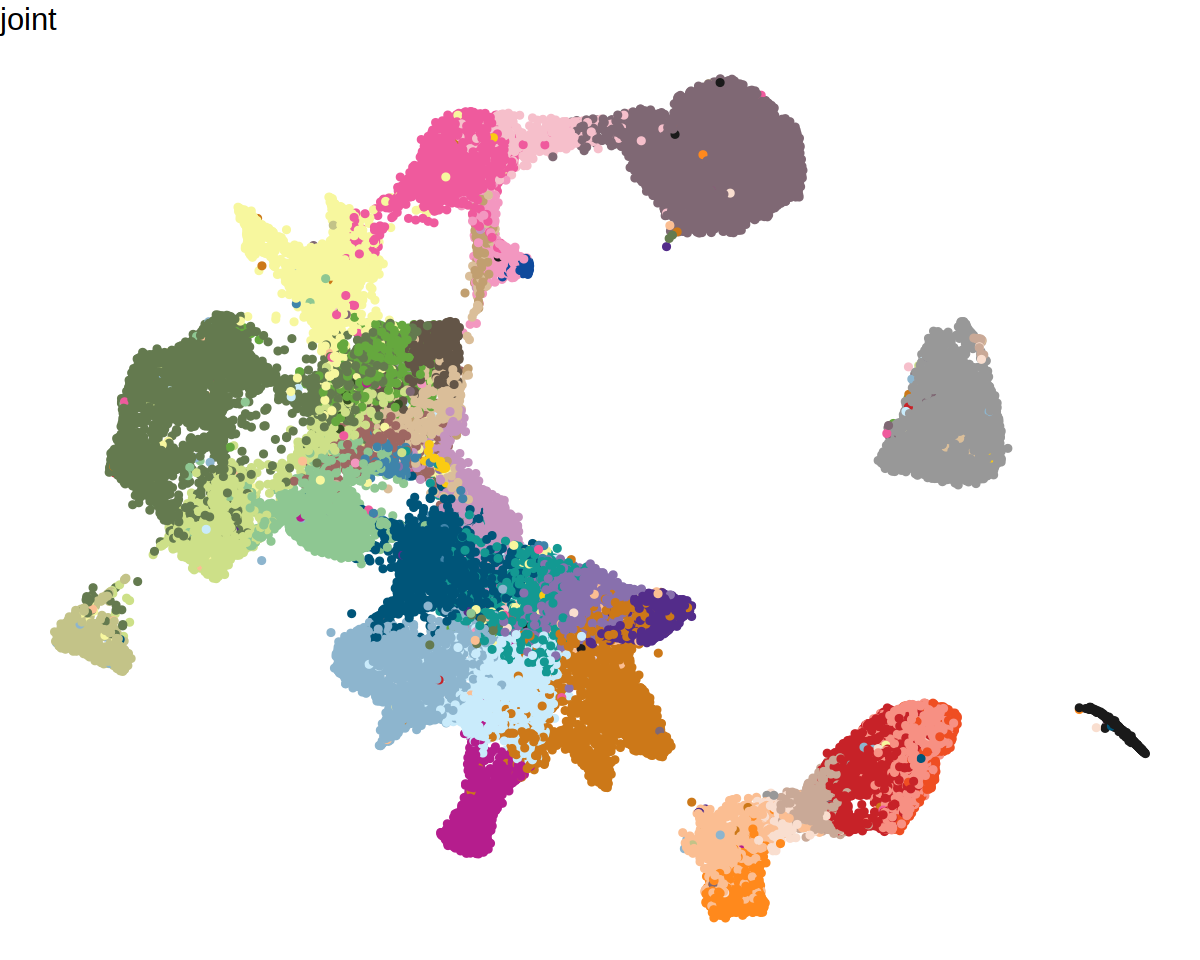

In [101]:
plot_umap('joint')

Scale for 'colour' is already present. Adding another scale for 'colour',
which will replace the existing scale.



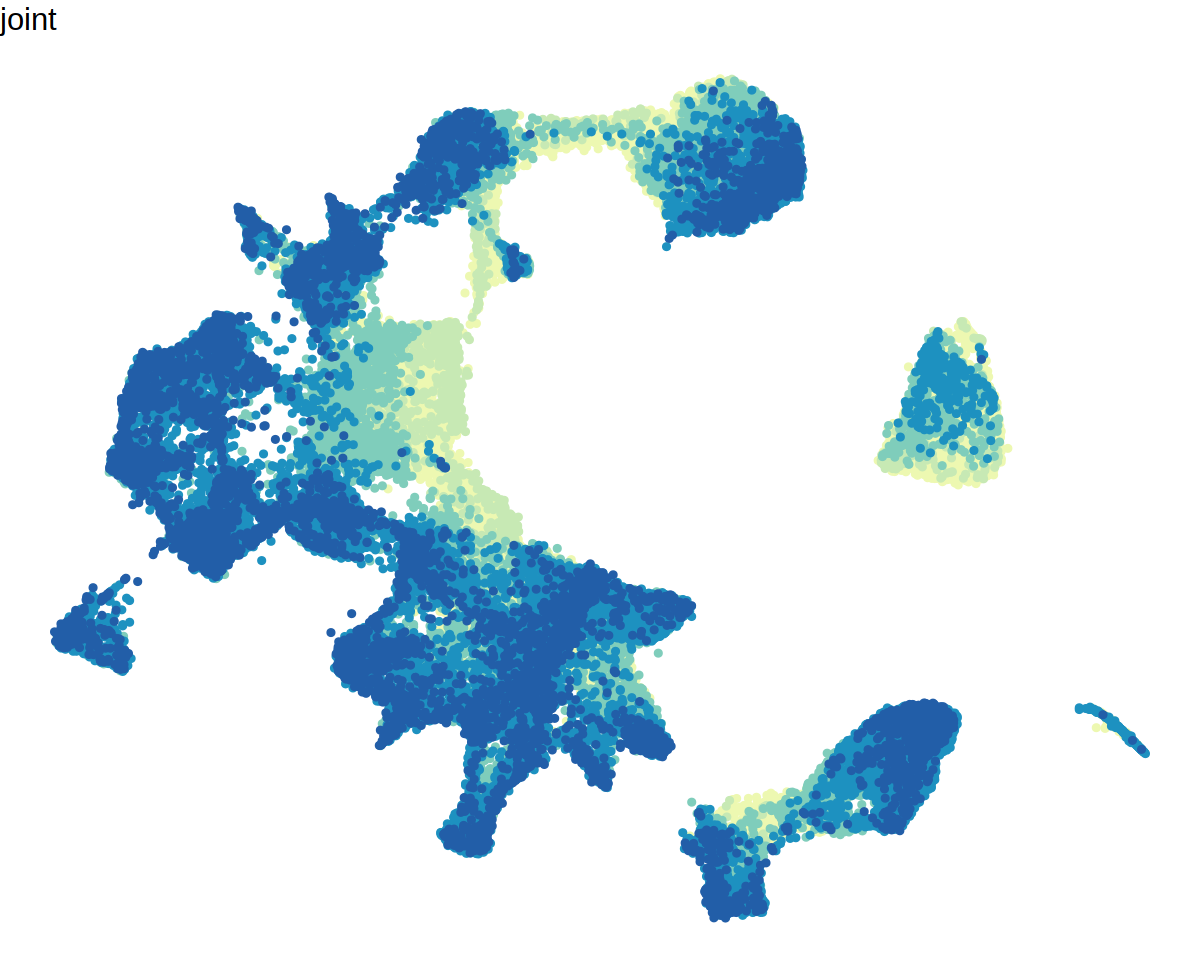

In [102]:
plot_umap('joint', colour='stage') + scale_color_manual(values=opts$stage.colors)

# Fewer dimensions

In [121]:
ATAC_dims = 30
RNA_dims = 30

joint_dimred = cbind(ATAC[,1:ATAC_dims], RNA[,2:(RNA_dims+1)])
cells = joint_dimred$cell
joint_dimred = as.data.table(apply(joint_dimred[,2:length(joint_dimred)], 2, scale))

In [122]:
meta = meta[cell %in% cells & order(match(cell, cells)),]

In [123]:
library(uwot)
options(repr.plot.width=10, repr.plot.height=8)
K = 15
nn = 20
mindist = 0.3

In [124]:
plot_umap = function(modality='RNA', colour='celltype'){
    ggplot(meta, aes_string(x=paste0(modality, '_umap1'), y=paste0(modality, '_umap2'), col=colour)) +
        geom_point() +
        ggtitle(modality) + 
        theme_void() + theme(text=element_text(size=15))
    }

In [125]:
# RNA 
RNA_UMAP = umap(RNA[,1:RNA_dims],
                n_neighbors = nn,
                min_dist = mindist)

RNA_UMAP = as.data.table(RNA_UMAP) %>%
    setnames(c('RNA_umap1', 'RNA_umap2')) %>% 
    .[, cell:=cells]

In [126]:
ATAC_UMAP = umap(ATAC[,2:ATAC_dims],
                n_neighbors = nn,
                min_dist = mindist)

ATAC_UMAP = as.data.table(ATAC_UMAP) %>%
    setnames(c('ATAC_umap1', 'ATAC_umap2')) %>% 
    .[, cell:=cells]

In [127]:
meta_new = meta %>% 
     merge(RNA_UMAP, by='cell') %>%  merge(ATAC_UMAP, by='cell')

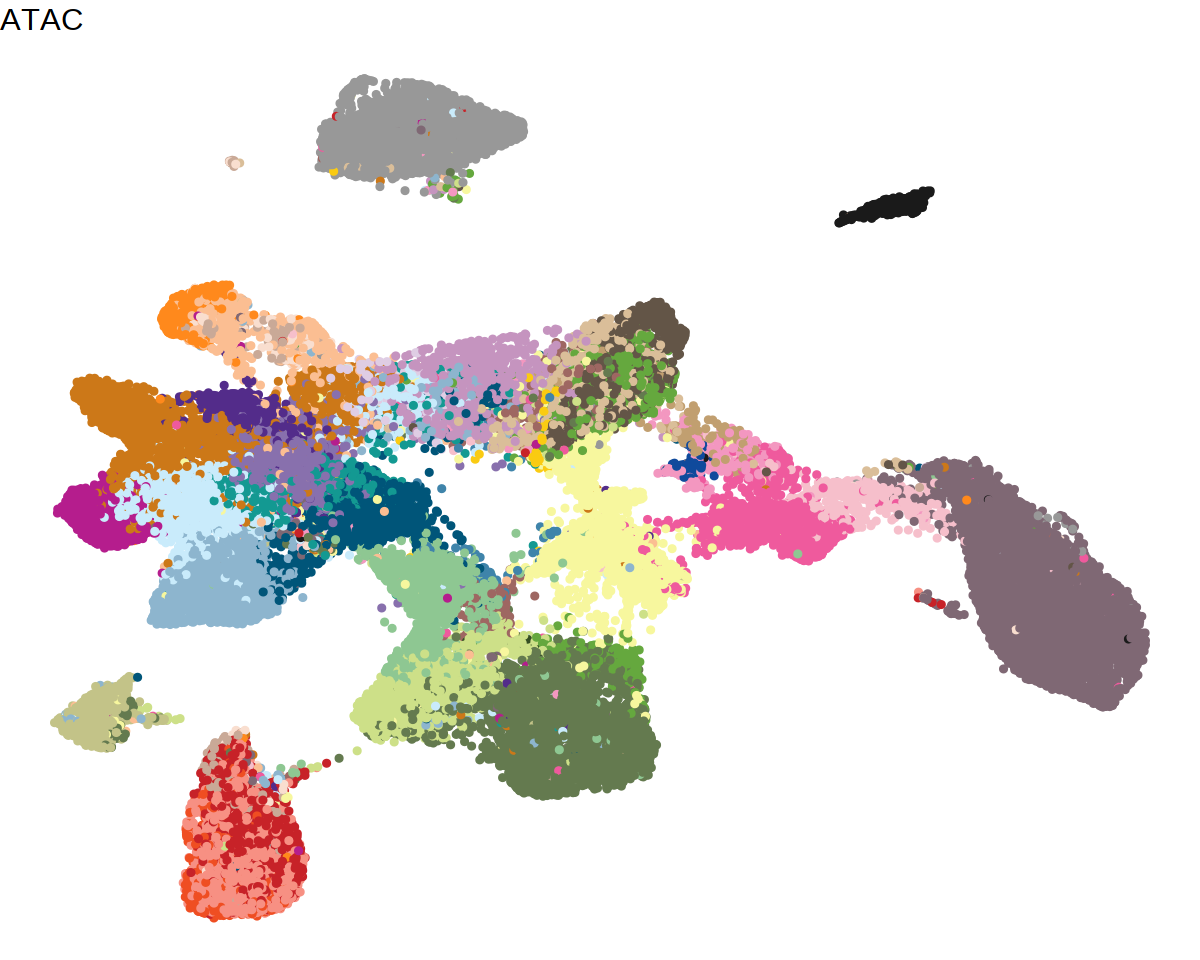

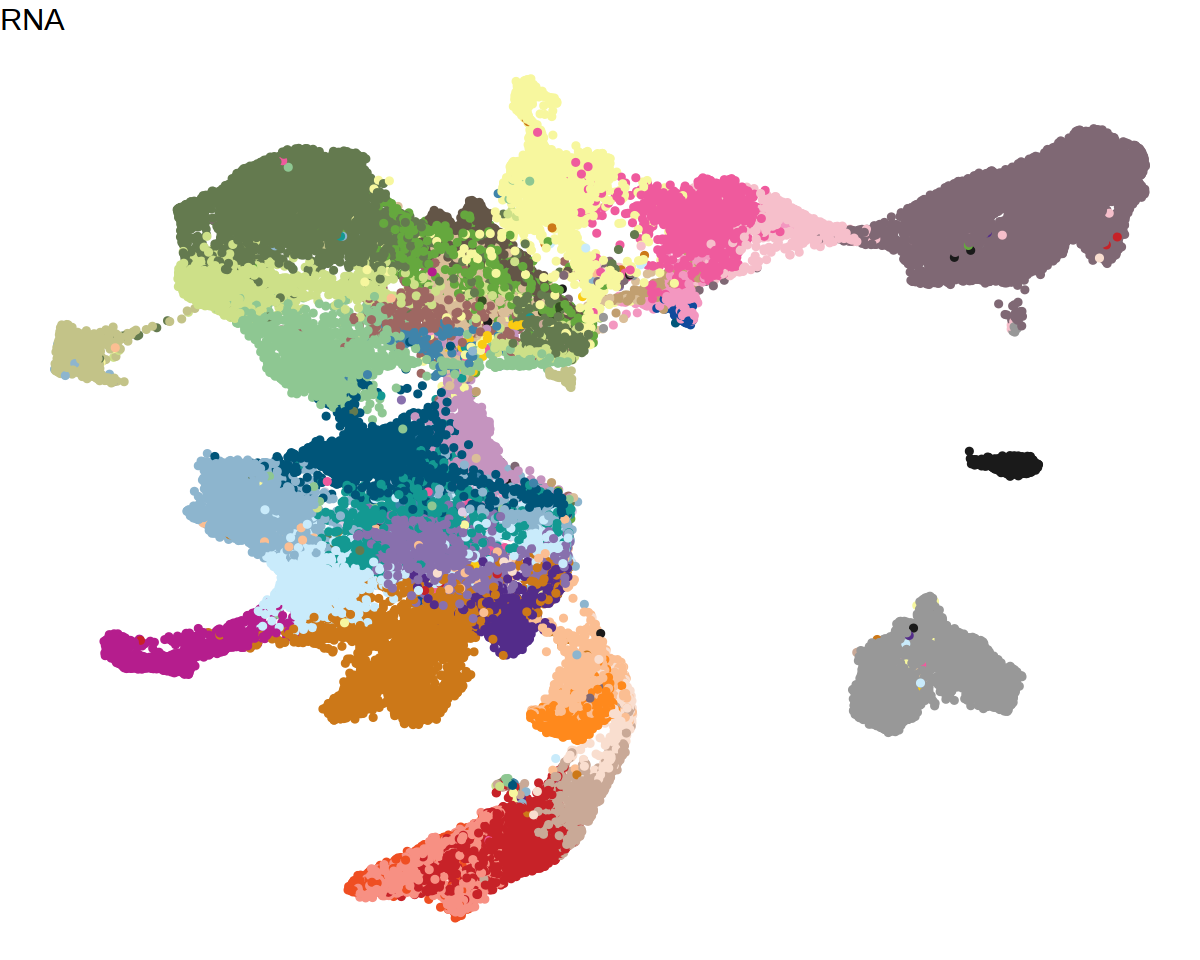

In [128]:
plot_umap = function(modality='RNA', colour='celltype'){
    ggplot(meta_new, aes_string(x=paste0(modality, '_umap1'), y=paste0(modality, '_umap2'), col=colour)) +
        geom_point() +
        ggtitle(modality) + scale_color_manual(values=opts$celltype.colors)+
        theme_void() + theme(text=element_text(size=15), legend.position='none')
    }
plot_umap('ATAC')
plot_umap('RNA')

In [129]:
joint_UMAP = umap(joint_dimred,
                n_neighbors = nn,
                min_dist = mindist)
joint_UMAP = as.data.table(joint_UMAP, keep.rownames=T) %>%
    setnames(c('joint_umap1', 'joint_umap2'))
  

In [130]:
meta_new = meta %>% cbind(joint_UMAP)

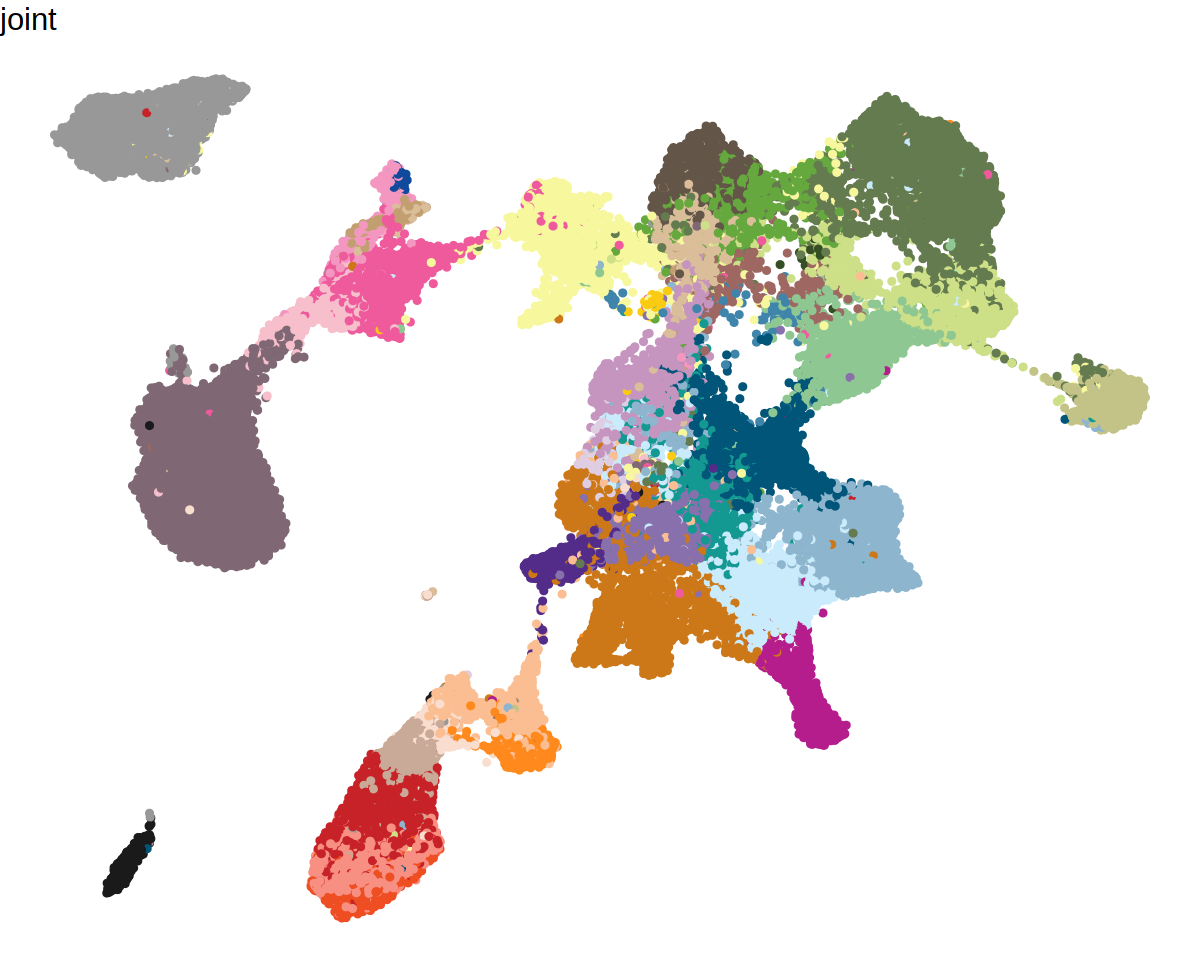

In [131]:
plot_umap('joint')

Scale for 'colour' is already present. Adding another scale for 'colour',
which will replace the existing scale.



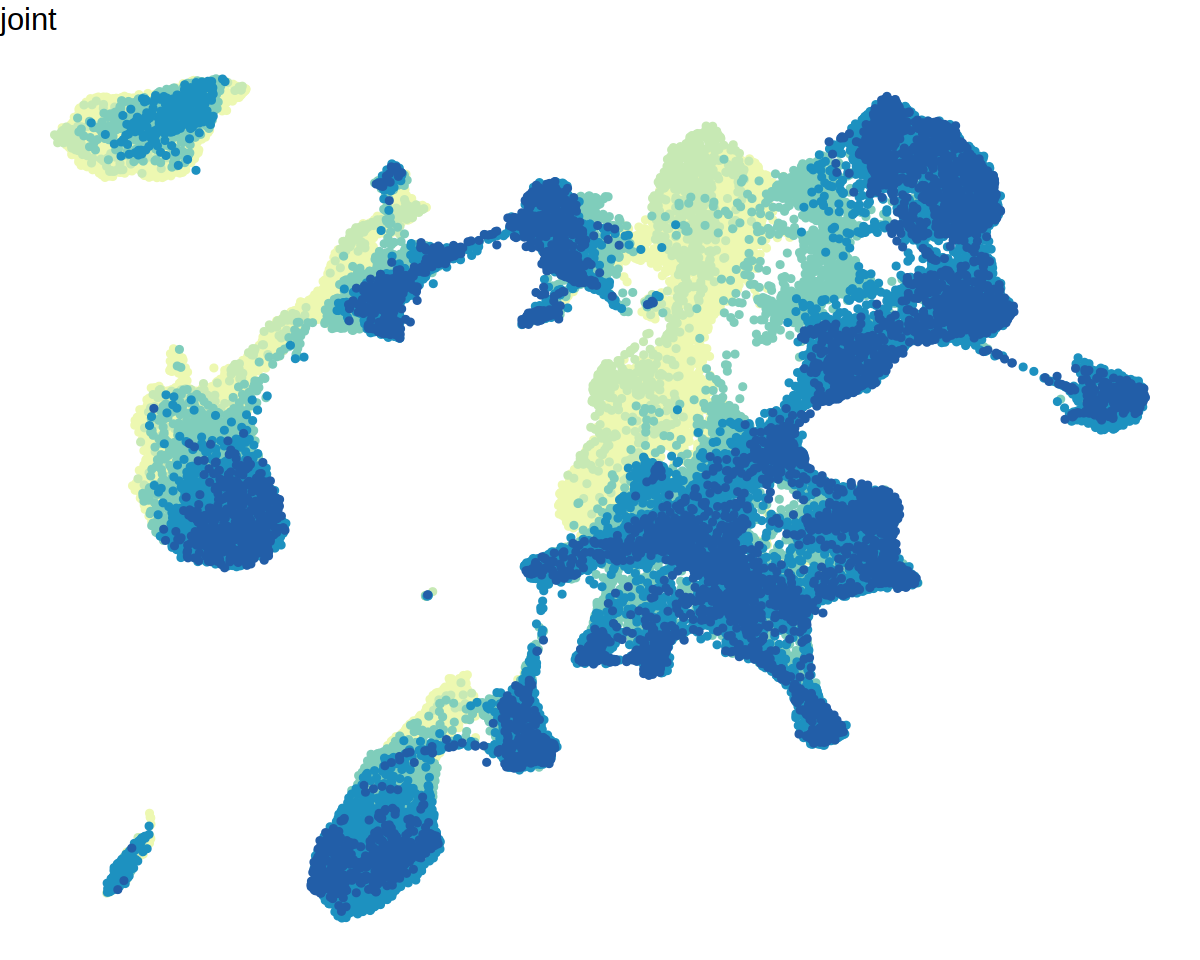

In [132]:
plot_umap('joint', colour='stage') + scale_color_manual(values=opts$stage.colors)

# diff number of dimensions

In [185]:
ATAC_dims = 25
RNA_dims = 25

joint_dimred = cbind(ATAC[,1:ATAC_dims], RNA[,2:(RNA_dims+1)])
cells = joint_dimred$cell
joint_dimred = as.data.table(apply(joint_dimred[,2:length(joint_dimred)], 2, scale))

In [186]:
meta = meta[cell %in% cells & order(match(cell, cells)),]

In [187]:
library(uwot)
options(repr.plot.width=10, repr.plot.height=8)
K = 15
nn = 20
mindist = 0.3

In [188]:
plot_umap = function(modality='RNA', colour='celltype'){
    ggplot(meta, aes_string(x=paste0(modality, '_umap1'), y=paste0(modality, '_umap2'), col=colour)) +
        geom_point() +
        ggtitle(modality) + 
        theme_void() + theme(text=element_text(size=15))
    }

In [189]:
# RNA 
RNA_UMAP = umap(RNA[,1:RNA_dims],
                n_neighbors = nn,
                min_dist = mindist)

RNA_UMAP = as.data.table(RNA_UMAP) %>%
    setnames(c('RNA_umap1', 'RNA_umap2')) %>% 
    .[, cell:=cells]

In [190]:
ATAC_UMAP = umap(ATAC[,2:ATAC_dims],
                n_neighbors = nn,
                min_dist = mindist)

ATAC_UMAP = as.data.table(ATAC_UMAP) %>%
    setnames(c('ATAC_umap1', 'ATAC_umap2')) %>% 
    .[, cell:=cells]

In [191]:
meta_new = meta %>% 
     merge(RNA_UMAP, by='cell') %>%  merge(ATAC_UMAP, by='cell')

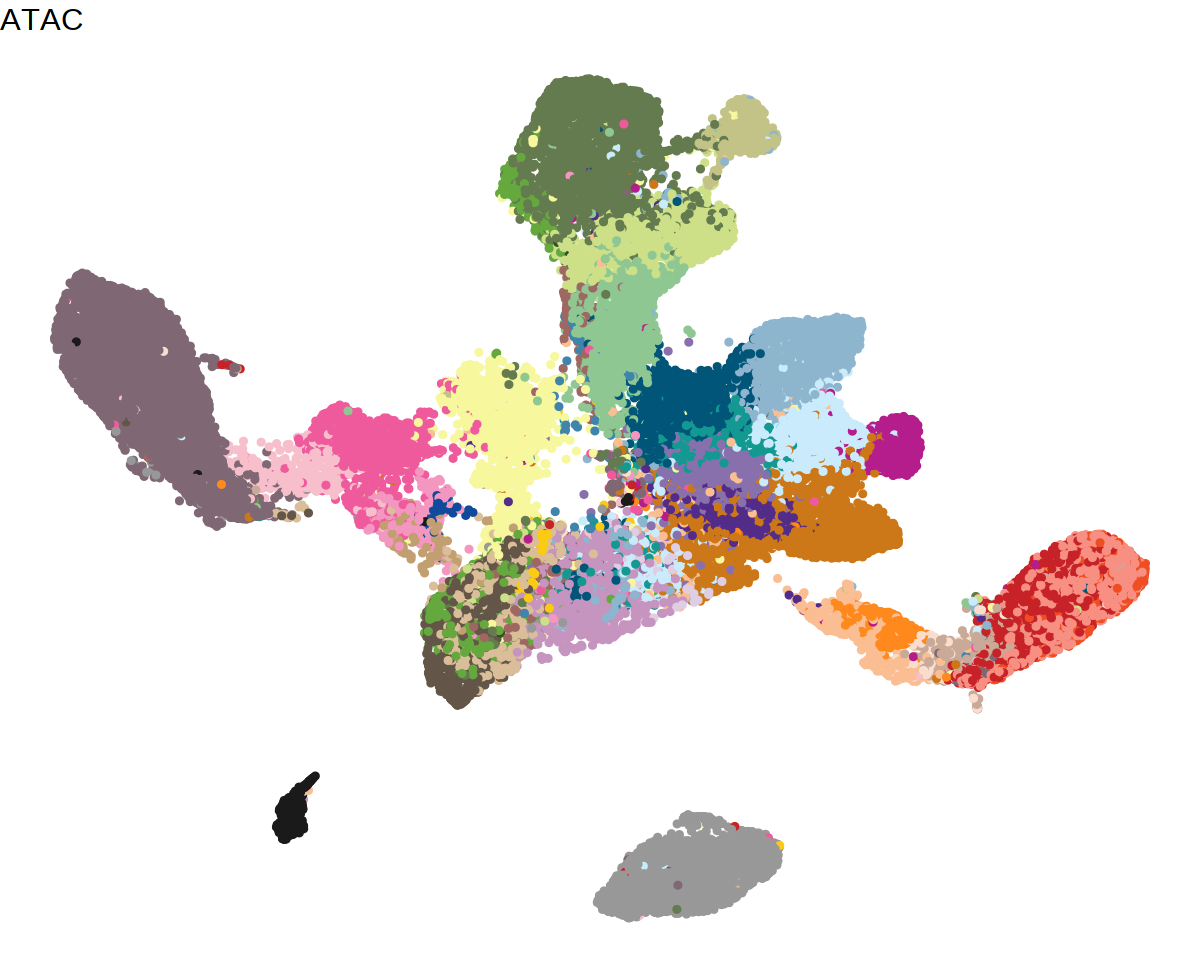

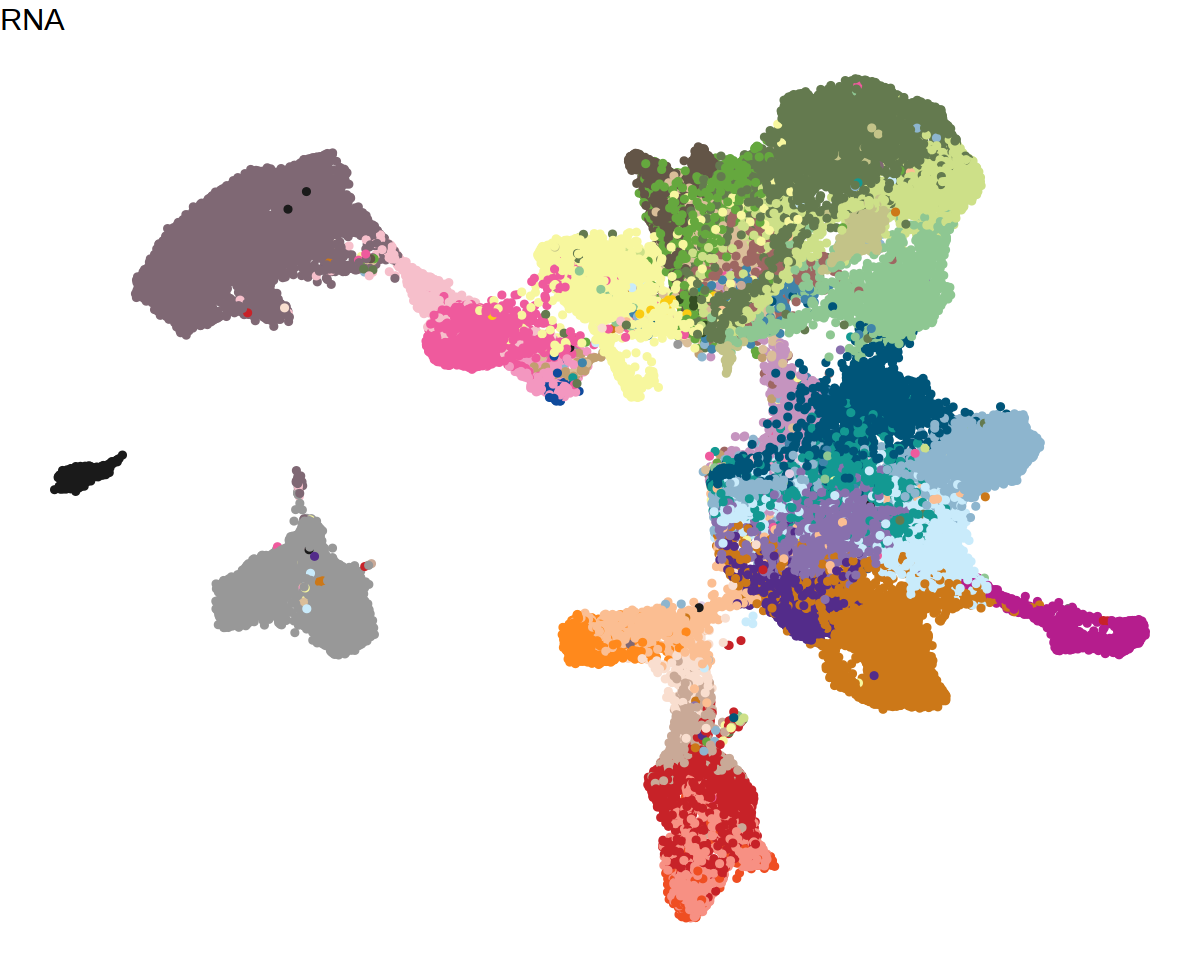

In [192]:
plot_umap = function(modality='RNA', colour='celltype'){
    ggplot(meta_new, aes_string(x=paste0(modality, '_umap1'), y=paste0(modality, '_umap2'), col=colour)) +
        geom_point() +
        ggtitle(modality) + scale_color_manual(values=opts$celltype.colors)+
        theme_void() + theme(text=element_text(size=15), legend.position='none')
    }
plot_umap('ATAC')
plot_umap('RNA')

In [193]:
joint_UMAP = umap(joint_dimred,
                n_neighbors = nn,
                min_dist = mindist)
joint_UMAP = as.data.table(joint_UMAP, keep.rownames=T) %>%
    setnames(c('joint_umap1', 'joint_umap2'))
  

In [194]:
meta_new = meta %>% cbind(joint_UMAP)

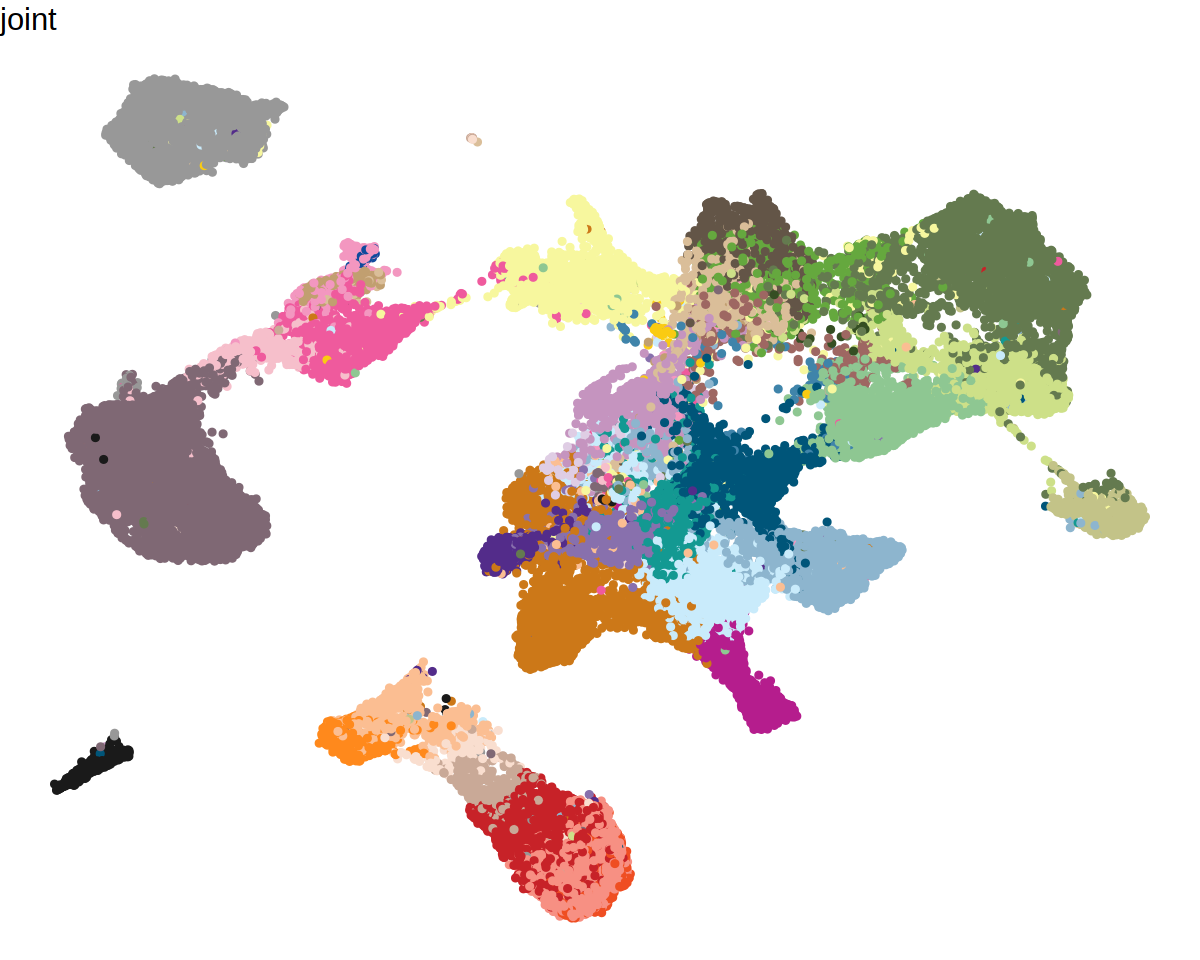

In [195]:
plot_umap('joint')

Scale for 'colour' is already present. Adding another scale for 'colour',
which will replace the existing scale.



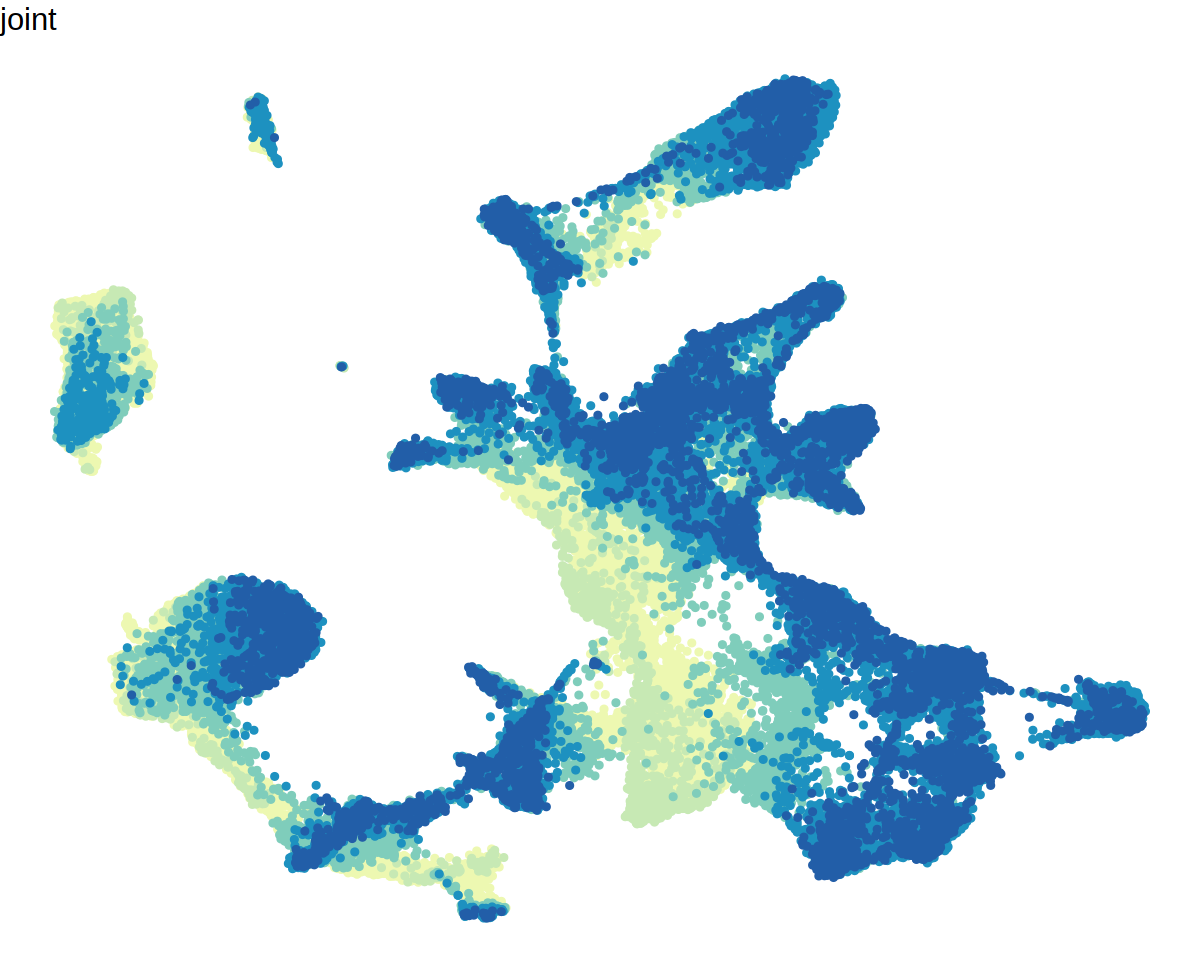

In [184]:
plot_umap('joint', colour='stage') + scale_color_manual(values=opts$stage.colors)